# Unit 3 - Convolutional neural networks (CNNs)

## 3.1. Introduction to CNNs

* __Computer Vision__
    - Every day, we’re interacting with deep vision models—via Google Photos, Google image search, YouTube, video filters in camera apps, OCR software, and many more. 
    - These models are also at the heart of cutting-edge research in autonomous driving, robotics, AI-assisted medical diagnosis, autonomous retail checkout systems, and even autonomous farming.
* __Computer vision and deep learning__
    - Computer vision is the earliest and biggest success story of deep learning. 
    - Computer vision is the problem domain that led to the initial rise of deep learning between 2011 and 2015.
    - Deep learning become dominant in the field since 2016.
    - __Convolutional neural networks (CNNs)__, also known as _convnets_, is the type of deep learning model that is now used almost universally in computer vision applications.
* **Main sources**:
    - François Chollet (2021). Deep Learning with Python, 2nd Ed. Manning
    - Mohamed Elgendy (2020). Deep Learning for Vision Systems. Manning

### 3.1.1 Drawbacks of simple neural networks for processing images

* Simple neural networks (also called Multi-Layer Perceptrons (MLPs) or "vanilla" neural networks) have several drawbacks when dealing image processing:

#### Spatial feature loss

* As we saw in previous units, before feeding an image to the hidden layers of an MLP, we must flatten the image matrix to a 1D vector.
* Flattening a 2D image to a 1D vector input results in losing the spatial features of the image.
* For example, pixels 1, 2, 5, and 6 form a square.
 
<img src="images/CNNs/spatial_feature_loss_1.png" width=169 height=169 />

* This spatial information is lost when flattening the image:
    - `Input vector = [1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]`
* MLPs have no knowledge of the fact that these pixel numbers were originally spatially arranged in a grid.

* Also the network can learn to identify a square, but only when the input nodes x1, x2, x5, and x6 are fired. 
* But what happens when we have new images with square shapes located in different areas in the image?

<img src="images/CNNs/spatial_feature_loss_2.png" width=379 height=169 />

* The MLP will have no idea that these are the shapes of squares because the network didn’t learn the square shape as a feature. 
* Instead, it learned the input nodes that, when fired, might lead to a square shape. 
* If we want our network to learn squares, we need a lot of square shapes located everywhere in the image. 
* This solution won’t scale for complex problems.

#### Number of parameters

* MLPs are composed of dense layers that are fully connected to each other. 
* Fully connected means every node in one layer is connected to all nodes of the previous layer and all nodes in the next layer. 
* This is not a big problem for the MNIST dataset because the images are really small in size (28 × 28).
* This can get out of control pretty fast and will not scale for bigger images.

<img src="images/CNNs/fully_connected_nn.png" width=400 height=400 />

### 3.1.2. Advantages of CNNs for processing images

#### Translation-invariance

* CNNs learn patterns that are translation-invariant. 
* After learning a certain pattern in the lower-right corner of a picture, a CNN can recognize it anywhere: for example, in the upper-left corner. 
* This makes CNNs data-efficient when processing images (because the visual world is fundamentally translation-invariant)
* They need fewer training samples to learn representations that have generalization power.
* CNNs, are locally connected layers: nodes are connected to only a small subset of the previous layers’ nodes, using fewer parameters than densely connected layers.

<img src="images/CNNs/locally_connected_nn.png" width=400 height=419 />

#### Spatial hierarchies of patterns

* CNNs can learn spatial hierarchies of patterns. 
* A first convolution layer will learn small local patterns such as edges, a second convolution layer will learn larger patterns made of the features of the first layers, and so on.
* This allows CNNs to efficiently learn increasingly complex and abstract visual concepts, because the visual world is fundamentally spatially hierarchical.

<img src="images/CNNs/spatial_hierarchy.png" width=505 height=427 />  

### 3.1.3. Basic architecture

* A convolutional neural network is composed of two types parts: a feature detection part and a classification part.

**Feature learning part**
* This part is mainly composed of:
    * Convolutional layers. 
    * Pooling layers.
* These layers intend to extract and detect features in the image.

**Classification part**
* The classification part is composed of:
    * A flatten layer as a result of the feature learning part.
    * A fully connected layer (FC) that outputs a vector of K dimensions where K is the number of classes that the network will be able to predict. This vector contains the probabilities for each class of any image being classified.
    * A final layer that uses a softmax function to provide the classification output.

<img src="images/CNNs/cnn_architecture_1.png" width=1691 height=842 /> 

## 3.2. Convolutional layer

<!-- * Sources: 
    * https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1
    * https://arxiv.org/abs/1603.07285 -->
* In mathematics, convolution is the operation of two functions to produce a third modified function. In the context of CNNs we have:
    * The first function is the input image.
    * The second function is the convolutional filter.
    * The result is a modified convolved image.

<img src="images/CNNs/convolutional_filter.png" width=694 height=449 />

###  3.2.1. Input feature map

* Our input data is a 2D matrix calle the *input feature map*. 
* The feature map is initially our image data.
* In subsequent layers it represents a mapping of where a certain kind of feature is found in the image, hence the name.

<img src="images/CNNs/input-feature-map.png" width=300 height=300 />

### 3.2.2. Filters

* A filter is composed by a _kernel_, which is simply a small matrix of weights, usually 3x3.

<img src="images/CNNs/kernel.png" width=200 height=200 />

### 3.2.3 Applying the convolution operation

* The kernel “slides” over the 2D input data, performing an elementwise multiplication with the part of the input it is currently on, and then summing up the results into a single output pixel.

<img src="images/CNNs/numerical_no_padding_no_strides.gif" width=401 height=224 />

<img src="images/CNNs/numerical_no_padding_no_strides_example.png" width=401 height=224 />

### 3.2.4 Filters rationale

* We use filters to extract features from the image. 
* In image processing, filters are used to filter out unwanted information or amplify features in an image. 
* These filters are matrices of numbers that convolve with the input image to modify it. 
* We use filters to detect different types of features: detect horizontal edges, detect vertical edges, detect more complex shapes like corners, and so on. 
* The point is that these filters, when applied in the convolutional layers, yield the feature-learning behavior we discussed earlier: first they learn simple features like edges and straight lines, and later layers learn more complex features.

<img src="images/CNNs/edge_detection_filter.png" width=1058 height=440 />

### 3.2.5 Padding

* __The convolution operaton shrinks the feature map__
    * Consider the 5 × 5 feature map (25 tiles total). 
    * There are only 9 tiles around which you can center a 3 × 3 window, forming a 3 × 3 grid (as saw before). 
    * Hence, the output feature map will be 3 × 3. It shrinks a little: by exactly two tiles alongside each dimension.
    
* __Padding__ (*relleno* in spanish).
    * If you want to get an output feature map with the same spatial dimensions as the input, you can use **padding**  
    * Padding consists of adding an appropriate number of rows and columns on each side of the input feature map so as to make it possible to fit center convolution windows around every input tile. 
    * For a 3 x 3 kernel over a 5 x 5 input, you add one column on the right, one column on the left, one row at the top, and one row at the bottom. 

![same_padding_no_strides.gif](images/CNNs/same_padding_no_strides.gif)

### 3.2.6 Strides

* Our description of convolution so far has assumed that the center tiles of the convolution windows are all contiguous. 
* But the distance between two successive windows is a parameter of the convolution, called its **stride** (*paso, zancada* in spanish)
* The previous convolutions have the stride to 1 (default stride or no stride).
* Using stride 2 means the width and height of the feature map are downsampled by a factor of 2 (in addition to any changes induced by border effects).
* Strided convolutions are rarely used in classification models, but they come in handy for some other types of models.

![no_padding_strides.gif](images/CNNs/no_padding_strides.gif)
![padding_strides.gif](images/CNNs/padding_strides.gif)

* The equation that give us the size of the output ($o$) given the size of the input feature map ($i$), the size of the kernel ($k$), the padding ($p$) and the stride ($s$) is the following:

$$
o = \left\lfloor \frac{i +2p - k}{s} \right\rfloor + 1
$$

* The symbol $ \left\lfloor \right\rfloor$ represents the *floor* operation, that takes as input a real number $x$, and gives as output the greatest integer less than or equal to $x$. That is, it truncates the fractional part of the number.

### 3.2.7. Multichannel images

* The diagrams above only deals with the case where the image has a single input channel. 
* In practicality, most input images have 3 channels.

![rgb_images.jpeg](images/CNNs/rgb_images.jpeg)

#### Filters and kernels

* Whereas in the 1 channel case, where the term **filter** and **kernel** are interchangeable, in the general case, they’re actually pretty different. 
* **Each filter actually happens to be a collection of kernels**, with there being one kernel for every single input channel to the layer, and each kernel being unique.
* **Each filter in a convolution layer produces one and only one output channel**, following this steps:

#### Process

* **Each filter in a convolution layer produces one and only one output channel**, following this steps:
    * Each of the kernels of the filter “slides” over their respective input channels, producing a processed version of each.
    * Each of the per-channel processed versions are then summed together to form one channel. The kernels of a filter each produce one version of each channel, and the filter as a whole produces one overall output channel.
    * Finally, then there’s the bias term. The way the bias term works here is that each output filter has one bias term. The bias gets added to the output channel so far to produce the final output channel.

_Example with one filter and three kernels (stride 2, no padding)_

<img src="images/CNNs/multi-channel_convolution_1.png" width=746 height=822 />

#### Multifilter

* In an image we apply not only one filter but several filters at the same time.
* The result of a convolution will be a new feature map, with dimensions probably reduced with respect to the original, and with a depth corresponding to the number of filters applied.

_Example with two filters and six kernels_

<img src="images/CNNs/multi-channel_convolution_2.png" width=729 height=784 />

### 3.2.8. Complete convolution process

<!--
Source: https://indoml.com/2018/03/07/student-notes-convolutional-neural-networks-cnn-introduction/
-->

A complete convolutional layer:
* Takes an input image composed of several layers.
* Applies several filters to the input image.
* Each filter is composed of several kernels, one for each channel.
* The result of each channel is summed together.
* Finally to make up a convolution layer, a bias is added and an activation function such as ReLU or tanh is applied.

![one-convolution-layer1.webp](images/CNNs/one-convolution-layer1.webp)

* The size of the input is the width and height of the image, with an input depth that represents each channel.
* The size of the output is determined by the parameters of the convolution (the size of the kernel, the padding and the stride -see before-), with an output depth that depends on the number of filters applied.

![cnn-simpler-notation-2.webp](images/CNNs/cnn-simpler-notation-2.webp)

### 3.2.9. The process of learning with convolutions

* **The filters are the trainable parameters of the convolutional layers**.
* These filters are initialized to small, random values.
* During network training, the filters are updated in a way that minimizes the loss. 

![learning_convolutions.png](images/CNNs/learning_convolutions.png)

* So **over the course of training, the filters will learn to detect certain features**, like edges and textures.
* Each filter is applied to all the image. If detecting a horizontal edge is important at some location in the image, it should intuitively be useful at some other location.
* **It is very important to realize that one does not hand-craft filters. These are learned automatically during training**, and that's the beauty of deep learning.

<!--* Example filters learned by a convolutional network:
![filters.jpeg](images/CNNs/filters.jpeg) -->

<!-- 
Sources:
* https://stackoverflow.com/questions/67439067/what-does-the-filter-parameter-mean-in-conv2d-layer
* https://cs231n.github.io/convolutional-networks/
* https://www.youtube.com/watch?v=r5nXYc2wYvI&list=PLypiXJdtIca5sxV7aE3-PS9fYX3vUdIOX&index=3&t=3122s
-->

### 3.2.10. Convolutions rationale

* __Multiple convolution layers => spatial hierarchies of patterns__ 
    * It is important to note that a CNN doesn’t go from the image input to the features vector directly in one layer. 
    * This usually happens in tens or hundreds of layers. 
    * The feature-learning process happens step by step after each hidden layer. 
       * The first layer usually learns very basic features like lines and edges.
       * The second assembles those lines into recognizable shapes, corners, and circles. 
       * Then, in the deeper layers, the network learns more complex shapes such as human hands, eyes, ears, and so on. 

![cnn_hierarchical_features.png](images/CNNs/cnn_hierarchical_features.png)

* __Convolution: locality and translation invariance__ 

    * We want to identify local patterns (locality), and we want to identify them no matter where they occurr in the image (translation invariance).
    * Convolutions apply __locality__ because they compute the weighted sum of a pixel with its immediate neighbors, rather than with all other pixels in the image.
    * Convolutions are __translate invariant__ because the same kernel is used across the image.

![locality_translation_invariance.png](images/CNNs/locality_translation_invariance.png)

## 3.3. Pooling

* In addition to discrete convolutions themselves, pooling operations make up another important building block in CNNs. 
* Pooling operations reduce the size of feature maps by using some function to summarize subregions, such as taking the average or the maximum value (the most common one).
* Pooling works by sliding a window across the input and feeding the content of the window to a pooling function. 

### 3.3.1. Pooling functions

#### Max-pool operation

_2x2 max-pool_

<img src="images/CNNs/max-pool_operation_2x2.png" width=800 />

_3x3 max-pool_

![max-pool_operation.png](images/CNNs/max-pool_operation.png)

#### Mean-pool operation

_3x3 mean-pool_

![mean-pool_operation.png](images/CNNs/mean-pool_operation.png)

### 3.3.2. Difference with convolutions

* __Function applied__
    * In some sense, pooling works very much like a discrete convolution, but replaces the linear combination described by the kernel with some other function.

* __Size__
    * A big difference from convolution is that max pooling is usually done with 2 × 2 windows and stride 2, in order to downsample the feature maps by a factor of 2. On the other hand, convolution is typically done with 3 × 3 windows and no stride (stride 1). 

* __Training__
    * Also convolutions include the trainable parameters of the network, pooling is a non-trainable operation.

### 3.3.3. Pooling rationale

* **The reason to use downsampling by pooling is**:
  * To reduce the number of feature-map coefficients to process.
  * To induce spatial-filter hierarchies by making successive convolution layers look at increasingly large windows (in terms of the fraction of the original input they cover).

#### Example

* Let’s now see how combining convolutions and downsampling can help us recognize larger structures.
* We start by applying a set of 3 × 3 kernels to a 8 × 8 image, obtaining a multichannel output image of the same size. 
* Then we scale down the output image by half, obtaining a 4 × 4 image, and apply another set of 3 × 3 kernels to it. 
* This second set of kernels operates on a 3 × 3 neighborhood of something that has been scaled down by half, so it effectively maps back to 8 × 8 neighborhoods of the input. 
* In addition, the second set of kernels takes the output of the first set of kernels (features like averages, edges, and so on) and extracts additional features on top of those.

![conv_pool_cross.png](images/CNNs/conv_pool_cross.png)

* So, on one hand, the first set of kernels operates on small neighborhoods on first-order, low-level features, while the second set of kernels effectively operates on wider neighborhoods, producing features that are compositions of the previous features. 
* This is a very powerful mechanism that provides convolutional neural networks with the ability to see into very complex scenes

#### Alternatives  
  * We can achieve such downsampling using strides in the prior convolution layer.
  * We can use average pooling instead of max pooling.
* **Max pooling tends to work better than these alternative solutions**.
  * It is better to first produce dense maps of features (via unstrided convolutions) and then look at the maximal activation of the features over small patches. <!--, rather than looking at sparser windows of the inputs (via strided convolutions) or averaging input patches, which could cause you to miss or dilute feature-presence information.-->
  * It’s more informative to look at the _maximal presence_ of different features than at their _average presence_.    

### 3.3.4. Feature map dimensions

####  Feature map depth

* After the convolutional layers, the feature map keeps its width and height dimensions (or shrinks a bit depending on the values of the padding and the stride).
* But the depth of the feature map gets deeper and deeper after each layer.
* We have to take into account that the depth is an arbitrary value (a parameter of our convolutional layer).
* The depth of the initial image are the RGB channels, but the depth of the different feature maps represent the number of filters used in each convolutional layer.

![feature_map_depth.png](images/CNNs/feature_map_depth.png)

#### Feature map size

* After the pooling layers, the image keeps its depth but shrinks in width and height, as explained before.

![feature_map_size.png](images/CNNs/feature_map_size.png)

####  Feature map evolution

* If the depth of the feature map progressively increases in the model, whereas the size of the feature map decreases, we will end up with a long tube of small shaped images that contain all the features in the original image.

* This is a pattern you’ll see in almost all CNNs. Why?

![feature_map_evolution.png](images/CNNs/feature_map_evolution.png)

* We already commented that the reason of downsampling the feature map (either with pooling or using strides) is useful to reduce the number of  coefficients to process and to look at increasingly large windows of the original image.

* __But why we increase the depth?__
    * Every layer of filters is there to capture patterns. 
        * For example, the first layer of filters captures patterns like edges, corners, dots etc. 
        * Subsequent layers combine those patterns to make bigger patterns (like combining edges to make squares, circles, etc.).
    * Now as we move forward in the layers, the patterns get more complex; hence there are larger combinations of patterns to capture.
    * That's why we increase the filter size in subsequent layers to capture as many combinations as possible.
    * The higher the number of filters, the higher the number of abstractions that your network is able to extract from image data. 

<!-- https://datascience.stackexchange.com/questions/55545/in-cnn-why-do-we-increase-the-number-of-filters-in-deeper-convolution-layers-fo -->

## 3.4. Fully connected layer

* After extracting the image features with the convolutional and pooling layers we need to classify our image into a class (a number, an animal, etc.).
* MLPs work great in classification problems, so we are going to use them. 
* This MLP is composed of: 
    * __Input flattened vector__: To feed the features tube to the MLP for classification, we flatten it to a vector with the dimensions (1, _n_). 
    * __Hidden layer/s__: We add one or more fully connected layers, and each layer has one or more neurons (similar to what we did when we built regular MLPs).
    * __Output layer__: We use the softmax activation function for classification problems involving more than two classes.



<img src="images/CNNs/fully_connected_layer.png" width=800 />

## 3.5. Our CNN first example (MNIST)

* First, let’s take a look at a simple convnet example that classifies MNIST digits.
* We performed before this task using a densely connected network and obtaining a test accuracy of 97.8%.
* A basic convnet is a stack of `Conv2D` and `MaxPooling2D` layers.
* We’ll build the model using the Keras Functional API.

### 3.5.1. Keras classes for CNNs

#### Convolutional classes

* A convolution layer is implemented in Keras using several classes: https://keras.io/api/layers/convolution_layers/
* The most used is the two-dimensional convolution represented by the `Conv2D` class: https://keras.io/api/layers/convolution_layers/convolution2d/
* __`Conv2D` class main parameters__
  - __`filters`__: Integer, the dimensionality of the output space (i.e. the number of output filters in the convolution)
  - __`kernel_size`__: An integer or tuple/list of 2 integers, specifying the height and width of the 2D convolution window. Can be a single integer to specify the same value for all spatial dimensions.
  - __`padding`__: one of `"valid"` or `"same"` (case-insensitive). `"valid"` means no padding. `"same"` results in padding with zeros evenly to the left/right or up/down of the input. When `padding="same" and strides=1, the output has the same size as the input.
  - __`strides`__: An integer or tuple/list of 2 integers, specifying the strides of the convolution along the height and width. Can be a single integer to specify the same value for all spatial dimensions.
  - __`activation`__: Activation function to use. If you don't specify anything, no activation is applied.

In [1]:
# Convolutional layer example

import keras
import numpy as np

x = np.random.rand(4, 10, 10, 16)
# 4 - The batch size (number of images in a batch).
# 10 - The height of each image.
# 10 - The width of each image.
# 16 - The number of channels (depth) of each image (feature map depth).

y = keras.layers.Conv2D(filters=32, 
                        kernel_size=3, 
                        padding="valid", 
                        strides=1,
                        activation='relu')(x)
print(y.shape)

# output dimensions
# 4 - Batch size (remains unchanged, same as input).
# 8 - Height of the output feature map (reduced from 10 due to convolution).
# 8 - Width of the output feature map (also reduced from 10 due to convolution).
# 32 - Number of output channels (filters) in the convolutional layer.

(4, 8, 8, 32)


#### Pooling classes
* A pooling layer is implemented in Keras using several classes: https://keras.io/api/layers/pooling_layers/
* The most used is the two-dimensional max pooling layer represented by the `MaxPooling2D` class: https://keras.io/api/layers/pooling_layers/max_pooling2d/
*  __`MaxPooling2D` class main parameters__
    - __`pool_size`__: Integer or tuple of 2 integers, window size over which to take the maximum. (2, 2) will take the max value over a 2x2 pooling window. If only one integer is specified, the same window length will be used for both dimensions.
    - __`padding`__: One of `"valid"` or `"same"` (case-insensitive). `"valid"` means no padding. `"same"` results in padding evenly to the left/right or up/down of the input such that output has the same height/width dimension as the input.
    - __`strides`__: Integer, tuple of 2 integers, or None. Strides values. Specifies how far the pooling window moves for each pooling step. If `None`, it will default to `pool_size`.

In [2]:
# strides=(1, 1) and padding="valid"
x = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [7., 8., 9.]])
# reshaped to 
# 1 - Batch size (1 sample).
# 3 - Height.
# 3 - Width.
# 1 - Number of channels (grayscale image).
x = np.reshape(x, [1, 3, 3, 1])

max_pool_2d = keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(1, 1), 
    padding="valid")
max_pool_2d(x)

# result matrix with shape (1, 2, 2, 1).
[5, 6]
[8, 9]

[8, 9]

In [3]:
# strides=(2, 2) and padding="valid"
x = np.array([[1.,  2.,  3.,  4.],
              [5.,  6.,  7.,  8.],
              [9., 10., 11., 12.]])
x = np.reshape(x, [1, 3, 4, 1])
max_pool_2d = keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2), 
    padding="valid")
max_pool_2d(x)

# result matrix with shape (1, 1, 2, 1).
# [6, 8]
# Last row should be [10, 12] but it is discarded due to the valid padding

<tf.Tensor: shape=(1, 1, 2, 1), dtype=float32, numpy=
array([[[[6.],
         [8.]]]], dtype=float32)>

In [4]:
# stride=(1, 1) and padding="same"
x = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [7., 8., 9.]])
x = np.reshape(x, [1, 3, 3, 1])
max_pool_2d = keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(1, 1), 
    padding="same")
max_pool_2d(x)

# result matrix with shape (1, 3, 3, 1).
# with "same" padding, extra padding is added around the edges 
# to ensure the output size matches the input size.
[5, 6, 6]
[8, 9, 9]
[8, 9, 9]

[8, 9, 9]

### 3.5.2. Instantiating a small CNN

* __Input__
  - A convolutional network takes as input tensors of shape `(image_height, image_width, image_channels)`, not including the batch dimension. 
  - In this case, we’ll configure the CNN to process inputs of size `(28, 28, 1)`, which is the format of MNIST images.
* __Feature detection layers__
  - Our feature detection layers is a stack of `Conv2D` and `MaxPooling2D` layers.
  - We can see that the output of every `Conv2D` and `MaxPooling2D` layer is a rank-3 tensor of shape (height, width, channels). 
  - The width and height dimensions tend to shrink as you go deeper in the model. 
  - The number of channels is controlled by the first argument (`filters`) passed to the `Conv2D` layers (32, 64, or 128).
  - After the last `Conv2D` layer, we end up with an output of shape (3, 3, 128)—a 3 × 3 feature map of 128 channels. 
* __Classification layers__
  - The next step is to feed this output into a densely connected classifier like those we’re already familiar with: a stack of `Dense` layers. 
  - These classifiers process vectors, which are 1D, whereas the current output is a rank-3 tensor. To bridge the gap, we flatten the 3D outputs to 1D with a `Flatten` layer before adding the `Dense` layers.
  - Finally, we do 10-way classification, so our last layer has 10 outputs and a `softmax` activation.

In [5]:
import keras
from keras import layers
inputs = keras.Input(shape=(28, 28, 1))

# Feature learning part
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)

# Classification part
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

#### Displaying the model's architecture

In [6]:
# Using the summary function
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

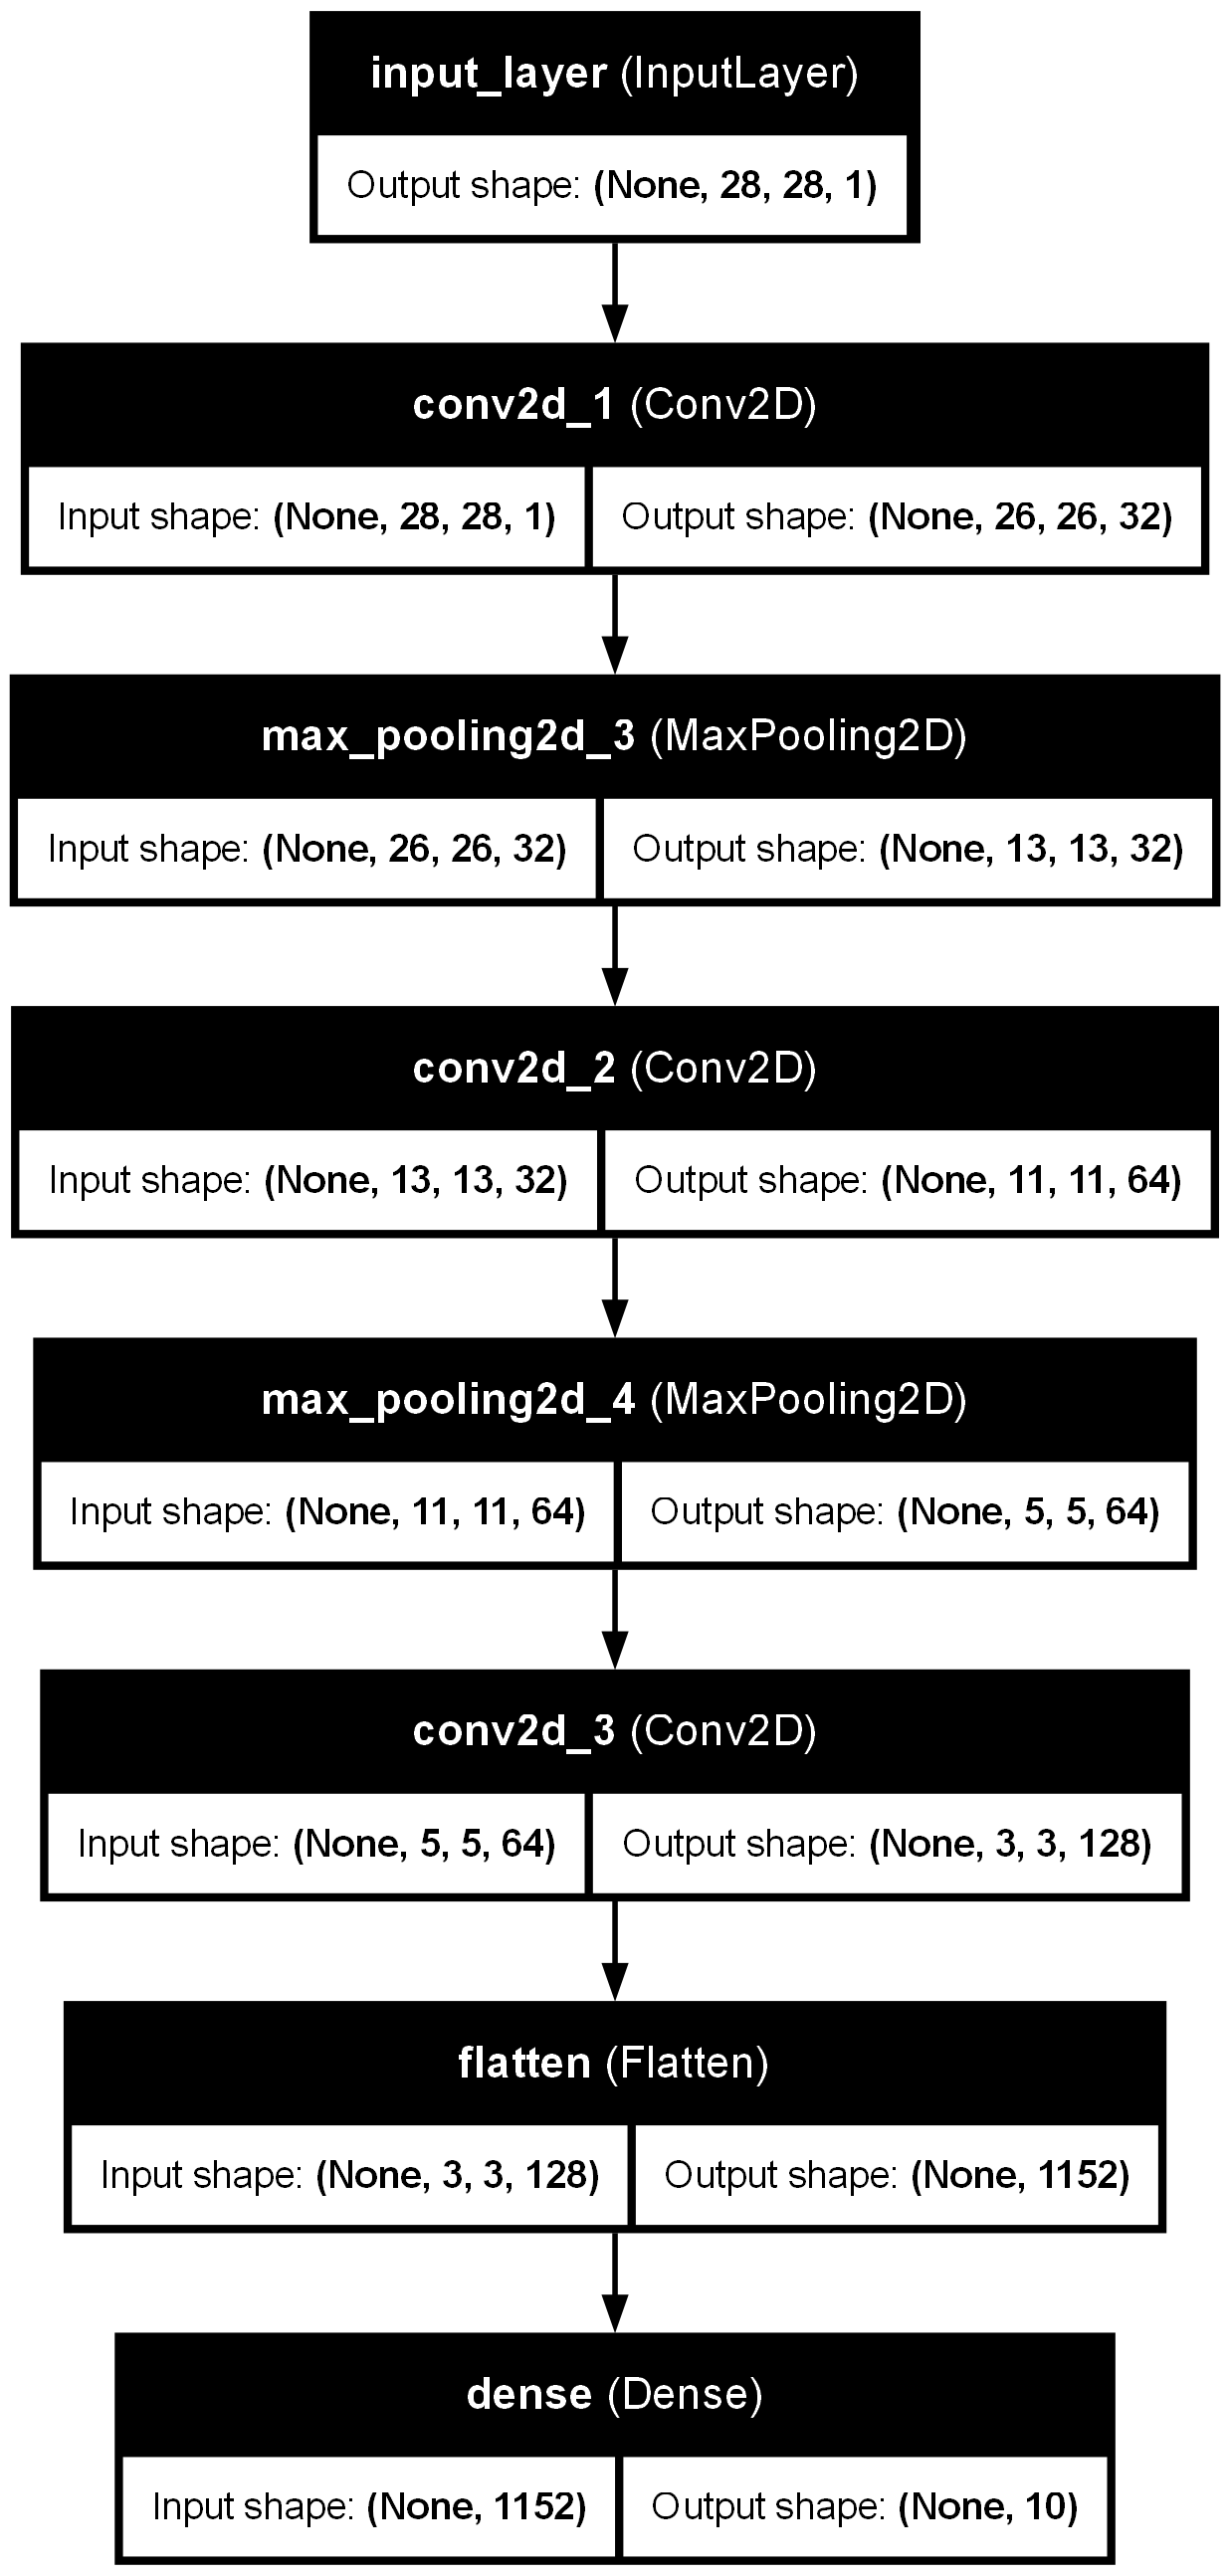

In [7]:
# Using the plot_model functionality
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

* __Using a custom graphical representation__

![convnet_mnist.png](images/CNNs/convnet_mnist.png)

* __Using the `visualkeras` library__

    - The functional model is only supporte for linear models where each layer has no more than one in or output.
    - Non-linear models will be shown in sequential order.
    - https://github.com/paulgavrikov/visualkeras

C:\Users\Usuario\anaconda3\envs\AP\Lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


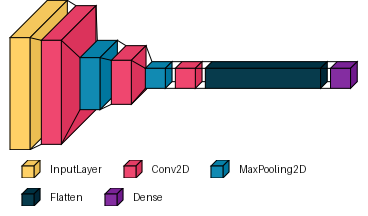

In [8]:
import visualkeras
# Result with legend
visualkeras.layered_view(model, legend=True)

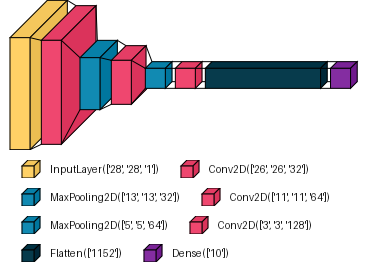

In [9]:
# Result with dimensions in the layer
visualkeras.layered_view(model, legend=True, show_dimension=True)

#### Training the CNN on MNIST images

* Let’s train the convnet on the MNIST digits. 
* Because we’re doing 10-way classification with a softmax output, we’ll use the categorical crossentropy loss
* Because our labels are integers, we’ll use the sparse version, `sparse_categorical_crossentropy`.

In [10]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255
model.compile(optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8843 - loss: 0.3691
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9857 - loss: 0.0460
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9903 - loss: 0.0318
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9931 - loss: 0.0224
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9946 - loss: 0.0164


#### Evaluating the CNN

In [11]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9876 - loss: 0.0452
Test accuracy: 0.991


* Whereas the densely connected model had a test accuracy of 97.8%, the basic convnet has a test accuracy of 99.1%
<!-- * We decreased the error rate by about 60% (relative). -->

## 3.6. CNN example on a small dataset (dogs vs. cats)

* We’ll focus on classifying images as dogs or cats in a dataset containing 5,000 pictures (2,500 cats, 2,500 dogs). 
* We’ll use 2,000 pictures for training, 1,000 for validation, and 2,000 for testing.
* We’ll start by training a small CNN without any regularization, to set a baseline for what can be achieved.
* When the overfitting issues appear, we will use regularization to avoid it.

### 3.6.1. Dataset

#### Original dataset

* The Dogs vs. Cats dataset isn’t packaged with Keras. 
* It was made available by Kaggle as part of a computer vision competition.
* You can download it from: https://www.kaggle.com/c/dogs-vs-cats/data
* This dataset contains 25,000 images of dogs and cats (12,500 from each class) and is 543 MB (compressed).
* Photos have different sizes, colors, backgrounds, etc.
  
<img src="images/CNNs/dogs-vs-cats_dataset.png" width=835 />

#### Reduced dataset

* We will work with a small subset of this dataset for these reasons:
    - It is easier to work with and faster to train a network with a smaller dataset.
    - It allows us to demonstrate that a DL model can learn from relatively small samples.
    - When the overfitting issues appear, we will use regularization to avoid it.
    - Demonstrate that, because CNNs learn local, translation-invariant features, they’re highly data-efficient on perceptual problems.

#### Code for reducing the dataset

* The following code takes the original data set from the `original_dir` and creates a reduced version on `new_base_dir`.
* The smaller version will have 2,000 pictures for training, 1,000 for validation, and 2,000 for testing extracted from the original train set.
* The smaller dataset is equally divided in dogs and cats for the training (1,000 samples of each class), validation (500 samples of each class) and test (1,000 samples of each class) sets.
* __You have available already the reduced version of the dataset, therefore you can skip running this conversion code.__

In [12]:
# code for converting original "cats vs. dogs" dataset in the smaller version.
import os, shutil, pathlib
import keras
  
# Use your specific paths here
original_dir = pathlib.Path("C:/datasets/dogs-vs-cats_original/train")
new_base_dir = pathlib.Path("C:/datasets/dogs-vs-cats_small")

In [13]:
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

            
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

* After running the previous code we will obtain the following directory structure:

```
dogs_vs_cats_small/
...train/
......cat/
......dog/
...validation/
......cat/
......dog/
...test/
......cat/
......dog/
```

* __NOTE: We have uploaded a ZIP file (108MB) with this small dataset to the virtual campus.__
* So there is now need to extract the dataset by yourself. Simply __update the `new_base_dir` path to the local path in which you have downloaded the small dataset__.

### 3.6.2. Preprocessing

#### Data preprocessing

* Data should be formatted into appropriately preprocessed floating-point tensors before being fed into the model. 
* The tasks to be done are:
    * Read the picture files.
    * Decode the JPEG content to RGB grids of pixels.
    * Convert these into floating-point tensors.
    * Resize them to a shared size (they do not have the same size) and also reduce the size to a more manageable one (180 × 180).
    * Pack them into batches (we’ll use batches of 32 images).    

#### Keras `image_dataset_from_directory()` function

* Keras has a utility function that does all the previous steps for us: `image_dataset_from_directory(directory)`
* See the documentation here: https://keras.io/api/preprocessing/image/
* __main arguments__:
    - `directory`: Directory where the data is located. If labels is `"inferred"`, it should contain subdirectories, each containing images for a class. 
    - `labels`: Either `"inferred"` (labels are generated from the directory structure), `None` (no labels), or a list/tuple of integer labels of the same size as the number of image files found in the directory.
    - `image_size`: Size to resize images to after they are read from disk, specified as `(height, width)`. Defaults to `(256, 256)`.
    - `batch_size`: Size of the batches of data. Defaults to `32`. If None, the data will not be batched (the dataset will yield individual samples).
    - `validation_split`: Optional float between 0 and 1, fraction of data to reserve for validation.
    - `interpolation`: The interpolation method used when resizing images. Defaults to `bilinear`.
    - `crop_to_aspect_ratio`: If `True`, resize the images without aspect ratio distortion by cropping the images. By default (`crop_to_aspect_ratio=False`), aspect ratio may not be preserved.
    - `pad_to_aspect_ratio`: If `True`, resize the images without aspect ratio distortion by using padding. By default (`pad_to_aspect_ratio=False`), aspect ratio may not be preserved.

In [14]:
# Using image_dataset_from_directory to read images

from keras.utils import image_dataset_from_directory
  
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


### 3.6.3. Building and training the CNN

#### Building the model

* The CNN will be a stack of alternated `Conv2D` (with relu activation) and `MaxPooling2D` layers, as in the MNIST example.
* Since the problem is more complex we'll make our model larger: with two more `Conv2D` and `MaxPooling2D` stages. 
* This allow us to augment the capacity of the model and to further reduce the size of the feature maps so they aren’t overly large when we reach the `Flatten` layer. 

In [15]:
from keras import layers
  
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

<img src="images/CNNs/convnet_cats_dogs.png" width=945 />

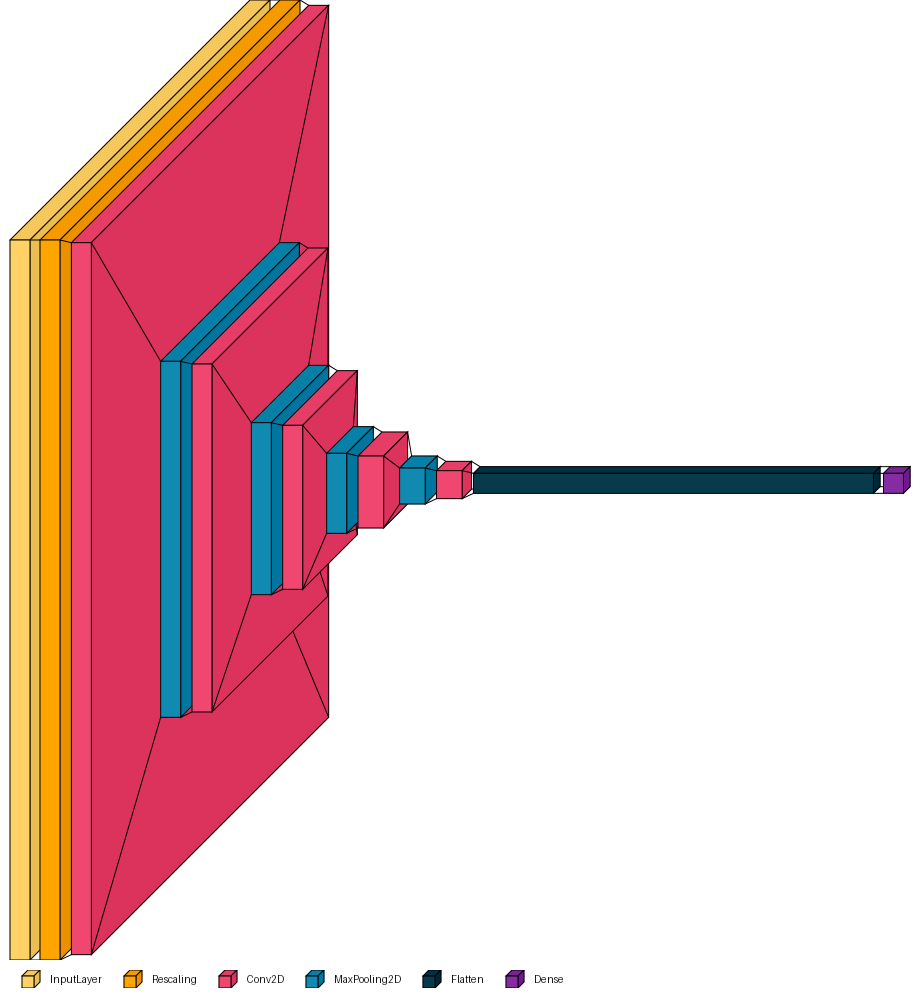

In [17]:
from collections import defaultdict
# visualkeras apply colors in order following a specified color wheel.
# Default color wheel of visual keras
# ["#ffd166", "#ef476f", "#118ab2", "#073b4c", "#842da1", "#ffbad4", "#fe9775", "#83d483", "#06d6a0", "#0cb0a9"]
# We can change the colors to mantain consistency

color_map = defaultdict(dict)
color_map[layers.Input]['fill'] = '#ffd166'
color_map[layers.Rescaling]['fill'] = 'orange'
color_map[layers.Conv2D]['fill'] = '#ef476f'
color_map[layers.MaxPooling2D]['fill'] = '#118ab2'
color_map[layers.Flatten]['fill'] = '#073b4c'
color_map[layers.Dense]['fill'] = '#842da1'

visualkeras.layered_view(model, legend=True, color_map=color_map)

In [18]:
# compilation step
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

#### Training the model with the `ModelCheckpoit` callback.

* We use a `ModelCheckpoint` callback to monitor de validation loss and tell the callback to only save a new file (overwriting any previous one) when the current value of the `val_loss` metric is lower than at any previous time during training.
* This guarantees that your saved file will always contain the state of the model corresponding to its best-performing training epoch, in terms of its performance on the validation data.
* As a result, we won’t have to retrain a new model for a lower number of epochs if we start overfitting: we can just reload our saved file.
* Main parameters:
    - `filepath`: `string` or `PathLike`, path to save the model file.
    - `save_best_only`: if `save_best_only=True`, it only saves when the model is considered the "best" and the latest best model according to the quantity monitored will not be overwritten. 
    - `monitor`: The metric name to monitor.
* See: https://keras.io/api/callbacks/model_checkpoint/

In [19]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="models/U3-CNNs/dogs-vs-cats_initial.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 223ms/step - accuracy: 0.4757 - loss: 0.7236 - val_accuracy: 0.6200 - val_loss: 0.6688
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.5287 - loss: 0.6916 - val_accuracy: 0.6010 - val_loss: 0.6741
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.5640 - loss: 0.6702 - val_accuracy: 0.5700 - val_loss: 0.6792
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.6019 - loss: 0.6568 - val_accuracy: 0.6030 - val_loss: 0.6614
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.6188 - loss: 0.6388 - val_accuracy: 0.5980 - val_loss: 0.7217
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.6050 - loss: 0.6648 - val_accuracy: 0.6110 - val_loss: 0.7183
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.6059 - loss: 0.6688 - val_accuracy: 0.7040 - val_loss: 0.5855
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.6830 - loss: 0.5743 - val_accu

In [20]:
import matplotlib.pyplot as plt

def plot(history):
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "b-o", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "r--o", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "b-o", label="Training loss")
    plt.plot(epochs, val_loss, "r-o", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()

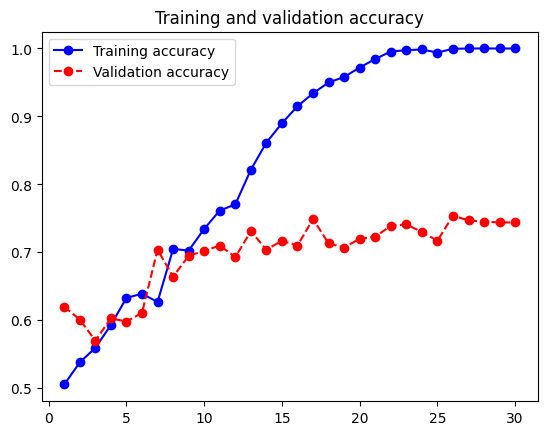

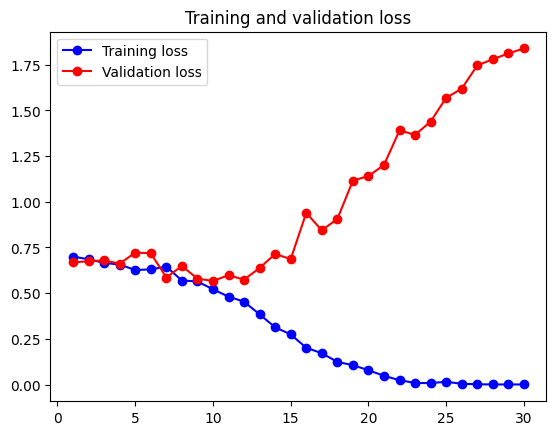

In [21]:
plot(history)

* These plots are characteristic of overfitting. 
* The training accuracy increases linearly over time, until it reaches nearly 100%, whereas the validation accuracy peaks at 75%. 
* The validation loss reaches its minimum after less than ten epochs and then starts to increase, whereas the training loss keeps decreasing linearly as training proceeds.

In [22]:
test_model = keras.models.load_model("models/U3-CNNs/dogs-vs-cats_initial.keras")
test_loss, test_acc = test_model.evaluate(test_dataset) 
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.6959 - loss: 0.5792
Test accuracy: 0.703


* We’ll reload the model from its saved file to evaluate it as it was before it started overfitting.
* The test accuracy is more or less 70%

### 3.6.4. Regularization using data augmentation and dropout

#### Data augmentation layers

* Overfitting is caused by having too few samples to learn from, rendering you unable to train a model that can generalize to new data.
* One easy technique to obtain new data when working with images is **data augmentation**.
* Data augmentation takes the approach of generating more training data from existing training samples by augmenting the samples via a number of random transformations that yield believable-looking images.
* This helps expose the model to more aspects of the data so it can generalize better.
* In Keras, this can be done by adding a number of data augmentation layers at the start of your model (see https://keras.io/api/layers/preprocessing_layers/image_augmentation/):
    - `RandomFlip` is a layer that randomly flip each image horizontally and vertically.
    - `RandomRotation` randomly rotates images. The `0.1` parameters indicates varying the value by a margin of [–10%, +10%]
    - `RandomRotation` randomly zooms images. The `0.2` parameters indicates varying the value by a margin of [–20%, +20%]   
* The goal is that, at training time, your model will never see the exact same picture twice. 

In [23]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

* Some examples of augmented images

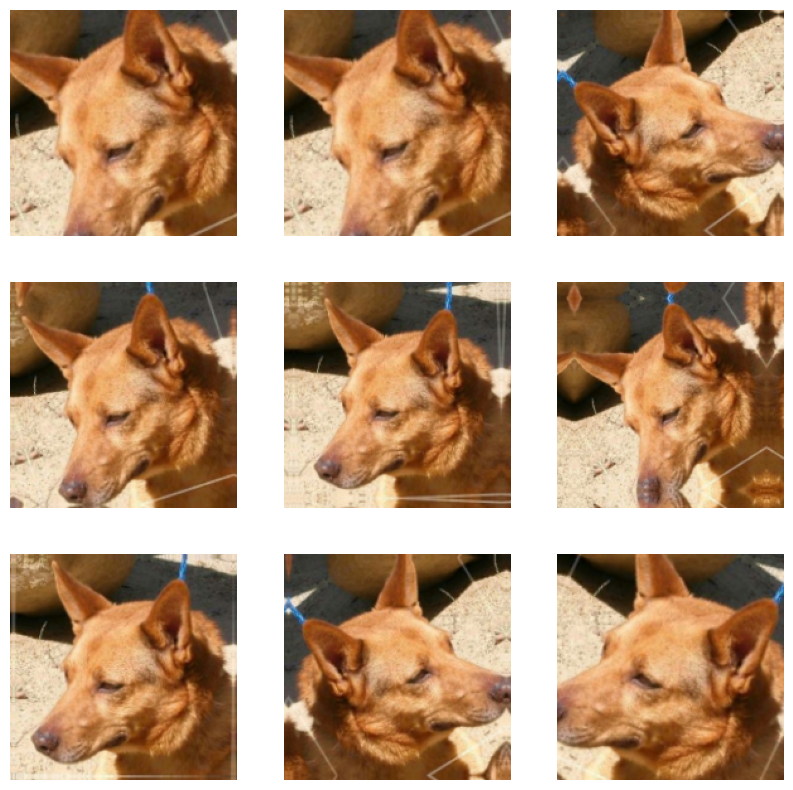

In [24]:
plt.figure(figsize=(10, 10)) 
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

* We also add a __dropout__ layer after the *flatten* to favor generalization.

In [25]:
# Defining a new CNN that includes image augmentation and dropout

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
  
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [26]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="models/U3-CNNs/dogs-vs-cats_augmentation.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=60,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 233ms/step - accuracy: 0.4943 - loss: 0.6983 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 232ms/step - accuracy: 0.5179 - loss: 0.6924 - val_accuracy: 0.5390 - val_loss: 0.6779
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 232ms/step - accuracy: 0.5737 - loss: 0.6876 - val_accuracy: 0.5280 - val_loss: 0.7527
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.6219 - loss: 0.6777 - val_accuracy: 0.5970 - val_loss: 0.6604
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.5930 - loss: 0.6777 - val_accuracy: 0.5810 - val_loss: 0.6642
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 230ms/step - accuracy: 0.6094 - loss: 0.6685 - val_accuracy: 0.6200 - val_loss: 0.6466
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.6497 - loss: 0.6432 - val_accuracy: 0.6310 - val_loss: 0.6487
Epoch 8/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 0.6509 - loss: 0.6429 - val_accu

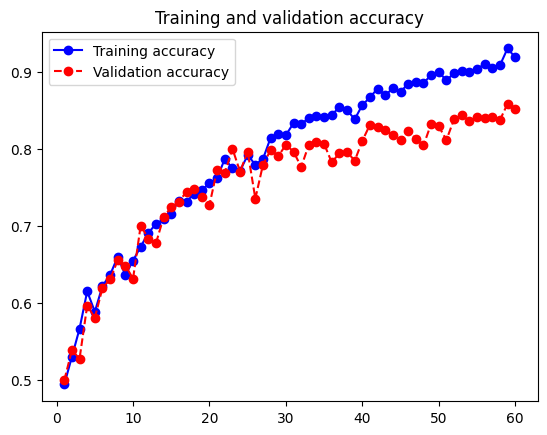

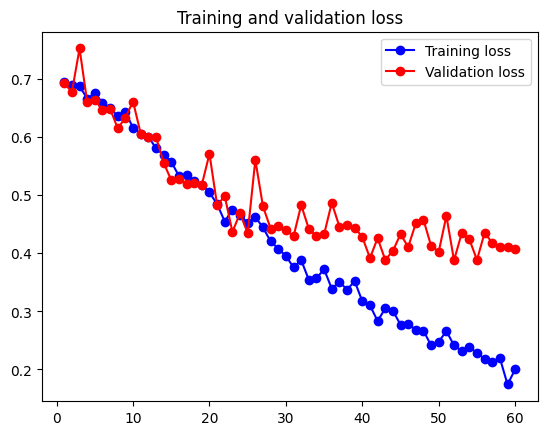

In [27]:
plot(history)

* Thanks to data augmentation and dropout, we start overfitting much later, around epochs 60–70 (compared to epoch 10 for the original model). 
* The validation accuracy ends up consistently in the 80–85% range—a big improvement over our first try.

In [28]:
test_model = keras.models.load_model(
    "models/U3-CNNs/dogs-vs-cats_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8328 - loss: 0.4394
Test accuracy: 0.837


## 3.7. Classic CNNs examples

### 3.7.1. LeNet-5

* From from Gradient-Based Learning Applied to Document Recognition paper by Y. Lecun, L. Bottou, Y. Bengio and P. Haffner (1998): http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf 
* Number of parameters:  ~ 60 thousands.

![lenet-52.webp](images/CNNs/lenet-52.webp)

### 3.7.2. AlexNet
* From ImageNet Classification with Deep Convolutional Neural Networks paper by Alex Krizhevsky, Geoffrey Hinton, and Ilya Sutskever (2012): https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf
* Number of parameters:  ~ 60 millions.

![alexnet.webp](images/CNNs/alexnet.webp)

### 3.7.3. VGG-16

* From Very Deep Convolutional Networks for Large-Scale Image Recognition paper by Karen Simonyan and Andrew Zisserman (2014): https://arxiv.org/abs/1409.1556
* The number 16 refers to the fact that the network has 16 trainable layers (i.e. layers that have weights).
* Number of parameters: ~ 138 millions.
* The strength is in the simplicity: the dimension is halved and the depth is increased on every step (or stack of layers)

![vgg16.png](images/CNNs/vgg16.png)